In [1]:
import os

os.environ["PATH"] = os.environ["PATH"] + ":/opt/homebrew/bin"

import datetime
from itertools import product
from functools import partial
from pathlib import Path

import altair as alt
import colormaps
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
import xarray as xr
from jetutils.anyspell import make_daily, mask_from_spells_pl
from jetutils.data import periodic_rolling_pl
from jetutils.definitions import (
    DATADIR,
    FIGURES,
    JJASDOYS,
    MONTH_NAMES,
    PRETTIER_VARNAME,
    FACTORS,
    FACTORS_UNITS,
    UNITS,
    polars_to_xarray,
)
from jetutils.geospatial import (
    compute_relative_anom,
    compute_relative_clim,
    compute_relative_sm,
    compute_relative_std,
    central_diff,
)
from jetutils.jet_finding import (
    average_jet_categories,
    extract_features,
    pers_from_cross_catd,
    spells_from_cross_catd_simple,
    track_jets,
)
from jetutils.plots import COLORS, COLORS_EXT, ascii_lowercase, num2tex, plot_interp
from jetutils.stats import create_bootstrapped_times
from matplotlib.colors import (
    BoundaryNorm,
    LinearSegmentedColormap,
    hsv_to_rgb,
    rgb_to_hsv,
)
from matplotlib.dates import DateFormatter, MonthLocator
from matplotlib.ticker import MaxNLocator
from scipy.stats import ttest_ind_from_stats, gaussian_kde, ks_2samp, ttest_ind, mannwhitneyu
from tqdm import tqdm, trange

alt.data_transformers.enable("vegafusion")

%load_ext IPython.extensions.autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

No shap


In [2]:
ALL_TIMES = (
    pl.datetime_range(
        start=pl.datetime(1959, 1, 1),
        end=pl.datetime(2023, 1, 1),
        closed="left",
        interval="6h",
        eager=True,
        time_unit="ms",
    )
    .rename("time")
    .to_frame()
)
summer_filter = ALL_TIMES.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9])).filter(
    pl.col("time").dt.ordinal_day() > 166
)
summer = summer_filter["time"]
summer_daily = summer.filter(summer.dt.hour() == 0)
big_summer = ALL_TIMES.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9]))
big_summer_daily = big_summer.filter(big_summer["time"].dt.hour() == 0)

summer_doy = summer_daily.dt.ordinal_day().unique()
n_bootstraps = 100

In [3]:
basepath_ctrl = Path(DATADIR).joinpath("Henrik_data/ctrl")

all_jets_one_df = pl.read_parquet(
    basepath_ctrl.joinpath("all_jets_one_df.parquet")
).cast({"time": pl.Datetime("ms")})

over_europe = pl.col("lon") > -10
lat_over_europe = (pl.col("lat") * pl.col("s")).filter(over_europe).sum() / pl.col(
    "s"
).filter(over_europe).sum()
lat_over_europe = all_jets_one_df.group_by("time", "jet ID").agg(
    lat_over_europe.fill_nan(0).alias("lat_over_europe")
)

props_uncat = pl.read_parquet(basepath_ctrl.joinpath("props_as_df_uncat.parquet")).cast(
    {"time": pl.Datetime("ms")}
)
props_uncat = props_uncat.join(lat_over_europe, on=["time", "jet ID"])

phat_filter = (pl.col("is_polar") < 0.5) | (
    (pl.col("is_polar") > 0.5) & (pl.col("int") > 1.0e8)
)
phat_jets = all_jets_one_df.filter(
    (pl.col("is_polar").mean().over(["time", "jet ID"]) < 0.5)
    | (
        (pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5)
        & (pl.col("int").mode().first().over(["time", "jet ID"]) > 1.0e8)
    )
)

jets_ctrl = phat_jets.with_columns(
    **{
        "jet ID": (pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5).cast(
            pl.UInt32()
        )
    }
)
phat_props = props_uncat.filter(phat_filter)
phat_props_catd = average_jet_categories(phat_props, polar_cutoff=0.5)
props_ctrl = phat_props_catd.join(
    phat_props_catd.rolling("time", period="2d", group_by="jet").agg(
        **{
            f"{col}_var": pl.col(col).var()
            for col in ["mean_lon", "mean_lat", "mean_s", "s_star"]
        }
    ),
    on=["time", "jet"],
)

cross_catd_ofile = basepath_ctrl.joinpath("cross_catd.parquet")
if cross_catd_ofile.is_file():
    cross_catd = pl.read_parquet(cross_catd_ofile)
else:
    cross_catd = track_jets(jets_ctrl)
    cross_catd.write_parquet(cross_catd_ofile)

pers = pers_from_cross_catd(cross_catd)
spells_ctrl = spells_from_cross_catd_simple(
    cross_catd,
    season=summer,
    q_STJ=0.795,
    q_EDJ=0.811,
    minlen=datetime.timedelta(days=5),
    smooth=datetime.timedelta(hours=24),
    fill_holes=datetime.timedelta(hours=18),
)

for jet in ["STJ", "EDJ"]:
    print(jet, spells_ctrl[jet]["spell"].n_unique())

daily_spells_ctrl = {
    a: make_daily(b, "spell", ["len", "spell_of"]) for a, b in spells_ctrl.items()
}

pers = pers.with_columns(
    jet=pl.when(pl.col("jet ID") == 0).then(pl.lit("STJ")).otherwise(pl.lit("EDJ"))
)[["time", "jet", "pers"]]
props_ctrl = props_ctrl.join(pers[["time", "jet", "pers"]], on=["time", "jet"])
props_ctrl = props_ctrl.with_columns(
    [
        pl.col(col)
        .replace([float("inf"), float("-inf"), float("nan")], None)
        .clip(pl.col(col).quantile(0.00001), pl.col(col).quantile(0.99999))
        for col in ["tilt", "waviness1", "wavinessDC16", "wavinessR16"]
    ]
)

props_ctrl_summer = summer_filter.join(props_ctrl, on="time")

STJ 30
EDJ 30


In [4]:
basepath_dobl = Path(DATADIR).joinpath("Henrik_data/dobl")

all_jets_one_df = pl.read_parquet(
    basepath_dobl.joinpath("all_jets_one_df.parquet")
).cast({"time": pl.Datetime("ms")})

over_europe = pl.col("lon") > -10
lat_over_europe = (pl.col("lat") * pl.col("s")).filter(over_europe).sum() / pl.col(
    "s"
).filter(over_europe).sum()
lat_over_europe = all_jets_one_df.group_by("time", "jet ID").agg(
    lat_over_europe.fill_nan(0).alias("lat_over_europe")
)

props_uncat = pl.read_parquet(basepath_dobl.joinpath("props_as_df_uncat.parquet")).cast(
    {"time": pl.Datetime("ms")}
)
props_uncat = props_uncat.join(lat_over_europe, on=["time", "jet ID"])

phat_filter = (pl.col("is_polar") < 0.5) | (
    (pl.col("is_polar") > 0.5) & (pl.col("int") > 1.0e8)
)
phat_jets = all_jets_one_df.filter(
    (pl.col("is_polar").mean().over(["time", "jet ID"]) < 0.5)
    | (
        (pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5)
        & (pl.col("int").mode().first().over(["time", "jet ID"]) > 1.0e8)
    )
)

jets_dobl = phat_jets.with_columns(
    **{
        "jet ID": (pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5).cast(
            pl.UInt32()
        )
    }
)
phat_props = props_uncat.filter(phat_filter)
phat_props_catd = average_jet_categories(phat_props, polar_cutoff=0.5)
props_dobl = phat_props_catd.join(
    phat_props_catd.rolling("time", period="2d", group_by="jet").agg(
        **{
            f"{col}_var": pl.col(col).var()
            for col in ["mean_lon", "mean_lat", "mean_s", "s_star"]
        }
    ),
    on=["time", "jet"],
)


cross_catd_ofile = basepath_dobl.joinpath("cross_catd.parquet")
if cross_catd_ofile.is_file():
    cross_catd = pl.read_parquet(cross_catd_ofile)
else:
    cross_catd = track_jets(jets_dobl)
    cross_catd.write_parquet(cross_catd_ofile)

pers = pers_from_cross_catd(cross_catd)
spells_dobl = spells_from_cross_catd_simple(
    cross_catd,
    season=summer,
    q_STJ=0.79,
    q_EDJ=0.78,
    minlen=datetime.timedelta(days=5),
    smooth=datetime.timedelta(hours=24),
    fill_holes=datetime.timedelta(hours=18),
)

for jet in ["STJ", "EDJ"]:
    print(jet, spells_dobl[jet]["spell"].n_unique())

daily_spells_dobl = {
    a: make_daily(b, "spell", ["len", "spell_of"]) for a, b in spells_dobl.items()
}

pers = pers.with_columns(
    jet=pl.when(pl.col("jet ID") == 0).then(pl.lit("STJ")).otherwise(pl.lit("EDJ"))
)[["time", "jet", "pers"]]
props_dobl = props_dobl.join(pers[["time", "jet", "pers"]], on=["time", "jet"])
props_dobl = props_dobl.with_columns(
    [
        pl.col(col)
        .replace([float("inf"), float("-inf"), float("nan")], None)
        .clip(pl.col(col).quantile(0.00001), pl.col(col).quantile(0.99999))
        for col in ["tilt", "waviness1", "wavinessDC16", "wavinessR16"]
    ]
)
props_dobl_summer = summer_filter.join(props_dobl, on="time")

STJ 30
EDJ 30


In [5]:
all_spells = {
    f"{exp_}_{jet}": dico[jet]
    for jet in ["STJ", "EDJ"]
    for exp_, dico in {"ctrl": spells_ctrl, "dobl": spells_dobl}.items()
}
summer_doy = summer_daily.dt.ordinal_day().unique()

# mean props

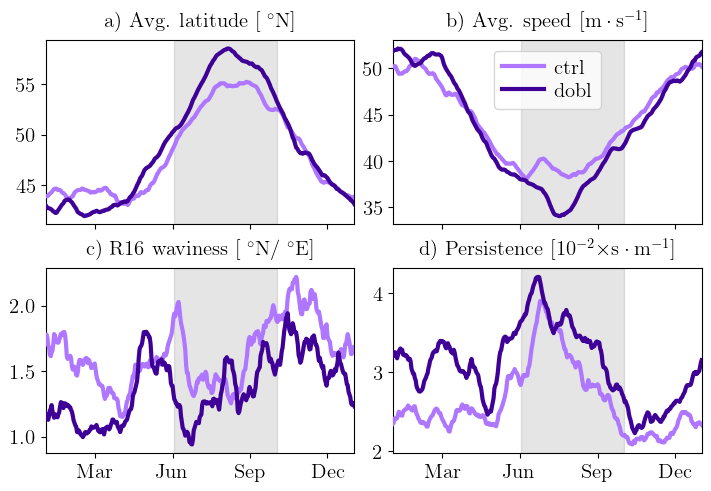

In [11]:
from matplotlib.lines import Line2D
# data_vars: list = ["mean_lat", "mean_s", "mean_theta", "tilt", "wavinessR16", "width", "pers", "int", "int_over_europe"]
data_vars: list = ["mean_lat", "mean_s", "wavinessR16", "pers"]
nrows: int = 2
ncols: int = 2

plot_kwargs = {"ctrl": [props_ctrl, "solid", COLORS_EXT[3]], "dobl": [props_dobl, "solid", COLORS_EXT[5]]}

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 3.5, nrows * 2.4),
    constrained_layout=True,
    sharex="all",
)
axes = axes.flatten()
jets = props_ctrl["jet"].unique().to_numpy()
njets = len(jets)
gb_args = [pl.col("time").dt.ordinal_day().alias("dayofyear"), pl.col("jet")]
aggs = [
    pl.col(col).replace([float("-inf"), float("inf"), float("nan")], None).mean()
    for col in data_vars
]


def _squarify(df: pl.DataFrame):
    return (
        pl.Series("dayofyear", np.arange(1, 367))
        .to_frame()
        .join(df["jet"].unique().sort(descending=True).to_frame(), how="cross")
        .join(df, how="left", on=["dayofyear", "jet"])
    )


for name, args in plot_kwargs.items():
    props, ls, color = args
    gb = props.group_by(gb_args)

    means = gb.agg(aggs).sort("dayofyear", "jet", descending=[False, True])
    means = _squarify(means)
    means = periodic_rolling_pl(means, 15, data_vars)

    x = means["dayofyear"].unique()
    color_order = [2, 1]
    for letter, varname, ax in zip(ascii_lowercase, data_vars, axes.ravel()):
        dji = varname == "double_jet_index"
        factor = FACTORS.get(varname, 1)
        if factor == 1:
            factor_str = ""
        else:
            factor_str = str(int(np.log10(np.abs(factor))))
            factor_str = r"$10^{" + factor_str + r"} \times $"
        ys = means[varname].to_numpy().reshape(366, njets)
        for i in range(njets):
            if i == 0:
                continue
            color = "black" if dji else color
            ax.plot(
                x,
                ys[:, i] / factor,
                lw=3,
                color=color,
                zorder=10,
                ls=ls,
                label=name,
            )
            if dji:
                break
        ax.set_title(
            f"{letter}) {PRETTIER_VARNAME.get(varname, varname)} [{factor_str}{UNITS.get(varname, '')}]"
        )  
        ax.xaxis.set_major_locator(MonthLocator(range(0, 13, 3)))
        ax.xaxis.set_major_formatter(DateFormatter("%b"))
        ax.set_xlim(min(x), max(x))
        if varname == "mean_lev":
            ax.invert_yaxis()
        if name == "dobl":
            ylim = ax.get_ylim()
            wherex = np.isin(x, JJASDOYS)
            ax.fill_between(
                x, *ylim, where=wherex, alpha=0.1, color="black", zorder=-10
            )
            ax.set_ylim(ylim)
           
axes.ravel()[1].legend(ncol=1, labelspacing=0.2, handletextpad=0.5, columnspacing=0.5).set_zorder(102)
fig.savefig(f"{FIGURES}/Diabatic/seasonal_pres.pdf")

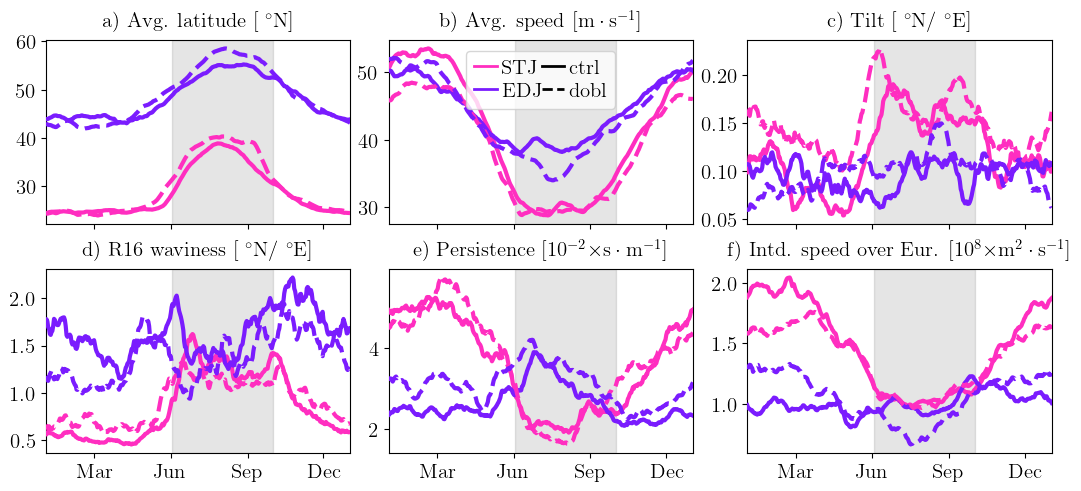

In [71]:
from matplotlib.lines import Line2D
# data_vars: list = ["mean_lat", "mean_s", "mean_theta", "tilt", "wavinessR16", "width", "pers", "int", "int_over_europe"]
data_vars: list = ["mean_lat", "mean_s", "tilt", "wavinessR16", "pers", "int_over_europe"]
nrows: int = 2
ncols: int = 3

plot_kwargs = {"ctrl": [props_ctrl, "solid"], "dobl": [props_dobl, "dashed"]}

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 3.5, nrows * 2.4),
    constrained_layout=True,
    sharex="all",
)
axes = axes.flatten()
jets = props_ctrl["jet"].unique().to_numpy()
njets = len(jets)
gb_args = [pl.col("time").dt.ordinal_day().alias("dayofyear"), pl.col("jet")]
aggs = [
    pl.col(col).replace([float("-inf"), float("inf"), float("nan")], None).mean()
    for col in data_vars
]


def _squarify(df: pl.DataFrame):
    return (
        pl.Series("dayofyear", np.arange(1, 367))
        .to_frame()
        .join(df["jet"].unique().sort(descending=True).to_frame(), how="cross")
        .join(df, how="left", on=["dayofyear", "jet"])
    )


for name, args in plot_kwargs.items():
    props, ls = args
    gb = props.group_by(gb_args)

    means = gb.agg(aggs).sort("dayofyear", "jet", descending=[False, True])
    means = _squarify(means)
    means = periodic_rolling_pl(means, 15, data_vars)

    x = means["dayofyear"].unique()
    color_order = [2, 1]
    for letter, varname, ax in zip(ascii_lowercase, data_vars, axes.ravel()):
        dji = varname == "double_jet_index"
        factor = FACTORS.get(varname, 1)
        if factor == 1:
            factor_str = ""
        else:
            factor_str = str(int(np.log10(np.abs(factor))))
            factor_str = r"$10^{" + factor_str + r"} \times $"
        ys = means[varname].to_numpy().reshape(366, njets)
        for i in range(njets):
            color = "black" if dji else COLORS[color_order[i]]
            ax.plot(
                x,
                ys[:, i] / factor,
                lw=3,
                color=color,
                zorder=10,
                ls=ls,
            )
            if dji:
                break
        ax.set_title(
            f"{letter}) {PRETTIER_VARNAME.get(varname, varname)} [{factor_str}{UNITS.get(varname, '')}]"
        )
        ax.xaxis.set_major_locator(MonthLocator(range(0, 13, 3)))
        ax.xaxis.set_major_formatter(DateFormatter("%b"))
        ax.set_xlim(min(x), max(x))
        if varname == "mean_lev":
            ax.invert_yaxis()
        if name == "dobl":
            ylim = ax.get_ylim()
            wherex = np.isin(x, JJASDOYS)
            ax.fill_between(
                x, *ylim, where=wherex, alpha=0.1, color="black", zorder=-10
            )
            ax.set_ylim(ylim)
           
linedata =  [[0, 1], [0, 1]]
handles = [
    Line2D(*linedata, lw=2, ls="solid", color=COLORS[2]),
    Line2D(*linedata, lw=2, ls="solid", color=COLORS[1]),
    Line2D(*linedata, lw=2, ls="solid", color="black"),
    Line2D(*linedata, lw=2, ls="dashed", color="black"),
]
labels = ["STJ", "EDJ", "ctrl", "dobl"]
axes.ravel()[1].legend(ncol=2, handles=handles, labels=labels, labelspacing=0.2, handletextpad=0.2, columnspacing=0.01, handlelength=1.1).set_zorder(102)
fig.savefig(f"{FIGURES}/Diabatic/seasonal.pdf")

# stats

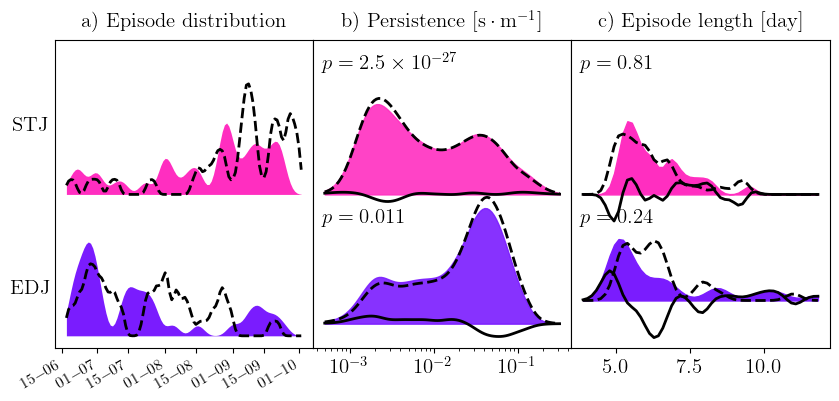

In [72]:
from matplotlib.dates import DateFormatter
from scipy.stats import ks_2samp

fig, axes = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw=dict(wspace=0, hspace=0))

ax = axes[0]
colors = [COLORS[2], COLORS[1]]
keys = list(spells_ctrl)
i = 1
otheralpha = 0.9
dy = 20
for key, val in spells_ctrl.items():
    huh = (
        summer.dt.ordinal_day()
        .unique()
        .sort()
        .to_frame()
        .with_columns(
            time_2=pl.datetime(year=1959, month=1, day=1) + pl.duration(days="time")
        )
    )
    to_plot = gaussian_kde(val["time"].dt.ordinal_day(), bw_method=0.08).evaluate(
        huh["time"]
    )
    ax.fill_between(
        huh["time_2"], i, i + dy * to_plot, color=colors[1 - i], alpha=1.0, lw=0
    )
    val = spells_dobl[key]
    to_plot = gaussian_kde(val["time"].dt.ordinal_day(), bw_method=0.04).evaluate(
        huh["time"]
    )
    ax.plot(huh["time_2"], i + dy * to_plot, color="black", lw=2, ls="dashed")
    i = i - 1
ax.xaxis.set_major_formatter(DateFormatter("%d-%m"))
ax.xaxis.set_tick_params(labelsize=11, rotation=30)
ticks = ax.get_xticks()
ticklabels = ax.get_xticklabels()
ax.set_xticks(ticks, labels=[t.get_text() for t in ticklabels], ha="right")
ax.set_yticks([0.35, 1.5], labels=keys[::-1])
ax.yaxis.set_tick_params(length=0)
ax.set_title("a) Episode distribution")
ylim = ax.get_ylim()
ax.set_ylim(ylim[0], 2 - ylim[0])

ax = axes[1]
dy = 1.0e0
bins = np.logspace(-3.3, -0.5, 101)
y1 = props_ctrl_summer.filter(pl.col("jet") == "STJ")["pers"]
y2 = props_dobl_summer.filter(pl.col("jet") == "STJ")["pers"]
y3 = props_ctrl_summer.filter(pl.col("jet") == "EDJ")["pers"]
y4 = props_dobl_summer.filter(pl.col("jet") == "EDJ")["pers"]

for i, (y, y_) in enumerate([(y1, y2), (y3, y4)]):
    y_smo = gaussian_kde(
        np.log10(y.replace(0, None).drop_nulls()), bw_method=0.2
    ).evaluate(np.log10(bins))
    y_smo = (1 - i) + dy * y_smo
    ax.fill_between(bins, (1 - i), y_smo, color=colors[i], alpha=otheralpha)
    # ax.plot(bins, y_smo, color=colors[i], lw=.5)

    y_smo_ = gaussian_kde(
        np.log10(y_.replace(0, None).drop_nulls()), bw_method=0.2
    ).evaluate(np.log10(bins))
    y_smo_ = (1 - i) + dy * y_smo_
    ax.plot(bins, y_smo_, color="black", lw=2, ls="dashed")

    ax.plot(bins, y_smo - y_smo_  + (1 - i), color="black", lw=2)

    _ = ax.annotate(
        f"$p={num2tex(ks_2samp(y, y_).pvalue, ncomma=2)}$",
        (0.03, 0.91 - 0.5 * (1 - i)),
        xycoords="axes fraction",
    )
ax.set_xscale("log")
ax.set_yticks([])
ax.set_title(f"b) Persistence [{UNITS['pers']}]")
ylim = ax.get_ylim()
ax.set_ylim(ylim[0], 2 - ylim[0])

ax = axes[2]
dy = 1.2e0
bins = np.arange(4, 12, 0.15) - 0.125

for i, jet in enumerate(["EDJ", "STJ"]):
    y = (
        spells_ctrl[jet].group_by("spell").agg(pl.col("len").first())["len"].to_numpy()
        / 4
    )
    y_smo = gaussian_kde(y, bw_method=0.2).evaluate(bins)
    y_smo = i + dy * y_smo
    ax.fill_between(bins, i, y_smo, color=colors[1 - i], alpha=1.0)
    # ax.plot(bins, y_smo, color=colors[i], lw=1)

    y_ = (
        spells_dobl[jet].group_by("spell").agg(pl.col("len").first())["len"].to_numpy()
        / 4
    )
    y_smo_ = gaussian_kde(y_, bw_method=0.2).evaluate(bins)
    y_smo_ = i + dy * y_smo_
    # ax.fill_between(bins, i, y_smo_, color=colors[i + 2], alpha=otheralpha)
    ax.plot(bins, y_smo_, color="black", lw=2, ls="dashed")

    ax.plot(bins, y_smo - y_smo_ + i, color="black", lw=2)

    p = ks_2samp(y, y_).pvalue
    _ = ax.annotate(
        f"$p={num2tex(p, ncomma=2)}$",
        (0.03, 0.91 - 0.5 * (1 - i)),
        xycoords="axes fraction",
    )
ax.set_yticks([])
ax.set_title("c) Episode length [day]")
ylim = ax.get_ylim()
ax.set_ylim(ylim[0], 2 - ylim[0])
fig.savefig(f"{FIGURES}/Diabatic/stats.pdf")

# interp around

In [6]:
variables = {
    "theta300:clim": [6, colormaps.amp, [315, 340]],
    "theta300:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "theta300:clim_grad": [8, colormaps.bilbao_r, [0, 20]],
    "theta300:anom_grad": [8, colormaps.BlWhRe, [-6, 6]],
    "s300:clim": [8, colormaps.amp, [0, 70]],
    "s300:anom": [8, colormaps.BlWhRe, [-5, 5]],
    "zeta300:clim": [8, colormaps.BlWhRe, [-10, 10]],
    "zeta300:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "z500:clim": [9, colormaps.lipari_r, [5400, 6000]],
    "z500:anom": [8, colormaps.BlWhRe, [-60, 60]],
    "t_low:clim": [6, colormaps.amp, [270, 302]],
    "t_low:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "DTCOND500:clim": [8, colormaps.amp, [0, 2.0]],
    "DTCOND500:anom": [8, colormaps.BlWhRe, [-0.6, 0.6]],
    "PTTEND500:clim": [6, colormaps.dense_r, [-1.2, -0.4]],
    "PTTEND500:anom": [8, colormaps.BlWhRe, [-0.6, 0.6]],
    "AAVO:clim": [8, colormaps.amp, [0, 50]],
    "AAVO:anom": [8, colormaps.BlWhRe, [-5, 5]],
    "CAVO:clim": [8, colormaps.amp, [0, 50]],
    "CAVO:anom": [8, colormaps.BlWhRe, [-5, 5]],
    "F1:clim": [8, colormaps.BlWhRe, [-3, 3]],
    "F1:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "F2:clim": [8, colormaps.BlWhRe, [-10, 10]],
    "F2:anom": [8, colormaps.BlWhRe, [-10, 10]],
    "F3:clim": [8, colormaps.BlWhRe, [-2, 2]],
    "F3:anom": [8, colormaps.BlWhRe, [-2, 2]],
    "hor:clim": [8, colormaps.BlWhRe, [-3, 3]],
    "hor:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "vert:clim": [8, colormaps.BlWhRe, [-3, 3]],
    "vert:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "vert_extra:clim": [8, colormaps.BlWhRe, [-2, 2]],
    "vert_extra:anom": [8, colormaps.BlWhRe, [-2, 2]],
}

In [ ]:
def do_one(varname, basepath, jet, spells, summer, n_bootstraps, factor, bias_correction: bool = False):
    varname, mode = varname.split(":")
    varname_no_number = varname.rstrip("0123456789")
    varname_ = f"{varname}_interp"
    grad = mode[-4:] == "grad"
    is_polar = jet == "EDJ"
    jet_id = int(is_polar)

    df = pl.scan_parquet(basepath.joinpath(f"{varname}_relative.parquet"))
    if varname_ not in df.collect_schema().names():
        if f"{varname_no_number}_interp" in df.collect_schema().names():
            df = df.rename({f"{varname_no_number}_interp": varname_})
        else:
            df = df.rename({"vort_interp": varname_})
    if "jet ID" not in df.collect_schema().names():
        df = df.with_columns(**{"jet ID": pl.col("is_polar").cast(pl.UInt32())})
    if bias_correction:
        bc = pl.scan_parquet(basepath.joinpath("bias_correction.parquet"))
        bc = bc.cast({
            "time": pl.Datetime("ms"),
            "n": pl.Float32(),
            "norm_index": pl.Float32(),
        })
        bc = bc.group_by("time", "jet ID", "norm_index").agg(pl.col("n").get(pl.col("n").abs().arg_min()))
        df = df.join(bc, on=["time", "jet ID", "norm_index"], how="left")
        df = df.with_columns(n = pl.col("n") - pl.col("n_right"))
        df = df.filter(pl.col("n").abs() < 2e6).drop("n_right")
    grad_expr = (
        (central_diff(pl.col(varname_).sort_by("n")) / central_diff(pl.col("n").sort()))
        * 1e6
    ).abs()
    if grad:
        df = df.with_columns(
            **{varname_: grad_expr.over("norm_index", "time", "jet ID")}
        )
    clim = compute_relative_clim(df, varname)
    if mode in ["clim", "clim_grad"]:
        to_plot = compute_relative_sm(clim, varname, summer_doy)
        to_plot = to_plot.filter(pl.col("dayofyear") == 1, pl.col("jet ID") == jet_id)
        to_plot = to_plot.drop("jet ID", "dayofyear")
        pvals = None
    else:
        to_plot = compute_relative_anom(df, varname, clim)
        ts_bootstrapped = create_bootstrapped_times(spells, summer, n_bootstraps).lazy()
        to_plot = (
            ts_bootstrapped.join(to_plot, on="time")
            .filter(pl.col("jet ID") == jet_id)
            .sort("sample_index", "spell", "inside_index", "norm_index", "n")
        )
        to_plot = to_plot.group_by(
            "sample_index", "norm_index", "n", maintain_order=True
        ).agg(pl.col(varname_).mean())
        pvals = (
            to_plot.group_by("norm_index", "n", maintain_order=True)
            .agg((pl.col(varname_).rank().last() - 1) / n_bootstraps)
            .sort("norm_index", "n")
        )
        pvals = pvals.with_columns(
            **{varname_: 2 * pl.min_horizontal(pl.col(varname_), 1 - pl.col(varname_))}
        )
        to_plot = (
            to_plot.filter(pl.col("sample_index") == n_bootstraps)
            .drop("sample_index")
            .sort("norm_index", "n")
        )
    to_plot = to_plot.with_columns(pl.col(varname_) * factor)
    to_plot = to_plot.collect()
    to_plot = polars_to_xarray(to_plot, ["norm_index", "n"]).T
    if pvals is not None:
        pvals = pvals.collect()
        pvals = polars_to_xarray(pvals, ["norm_index", "n"]).T
    return to_plot, pvals


during_filter = [
    pl.col("relative_time") >= pl.duration(days=0),
    pl.col("relative_time") <= pl.duration(days=5),
]
n_bootstraps = 100
break_signal = False
bias_correction : bool = True
suffix = "_bc" if bias_correction else ""
for exp_, jet in product(["ctrl", "dobl"], ["STJ", "EDJ"]):
    if break_signal:
        break
    is_polar = jet == "EDJ"
    spells = all_spells[f"{exp_}_{jet}"]
    basepath = Path(DATADIR, "Henrik_data", exp_)
    nspells = spells["spell"].n_unique()
    spells = spells.filter(*during_filter)
    for varname in tqdm(variables):
        varname_, rest = varname.split(":")
        factor = FACTORS_UNITS.get(varname_.rstrip("035"), 1)
        ofile = Path(f"{FIGURES}/Diabatic/figure_data/{exp_}_{jet}_{varname}{suffix}.nc")
        ofile_pvals = Path(
            f"{FIGURES}/Diabatic/figure_data/{exp_}_{jet}_{varname}{suffix}_pvals.nc"
        )
        if ofile.is_file():
            continue
        to_plot, pvals = do_one(
            varname, basepath, jet, spells, summer, n_bootstraps, factor, bias_correction=bias_correction
        )
        if to_plot.shape == (0, 0):
            # break_signal = True
            print(jet, exp_, varname)
            # break
        to_plot.to_netcdf(ofile)
        if pvals is not None:
            pvals.to_netcdf(ofile_pvals)

100%|██████████| 32/32 [00:00<00:00, 8190.00it/s]


In [8]:
variables = {
    "hor:clim": [8, colormaps.BlWhRe, [-10, 10]],
    "hor:anom": [8, colormaps.BlWhRe, [-10, 10]],
    "vert:clim": [8, colormaps.BlWhRe, [-10, 10]],
    "vert:anom": [8, colormaps.BlWhRe, [-10, 10]],
    "vert_extra:clim": [8, colormaps.BlWhRe, [-2, 2]],
    "vert_extra:anom": [8, colormaps.BlWhRe, [-2, 2]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/EPF")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["ctrl", "dobl"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()

In [76]:
variables = {
    "AAVO:clim": [8, colormaps.amp, [0, 40]],
    "AAVO:anom": [8, colormaps.BlWhRe, [-10, 10]],
    "CAVO:clim": [8, colormaps.amp, [0, 40]],
    "CAVO:anom": [8, colormaps.BlWhRe, [-10, 10]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/RWB")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["ctrl", "dobl"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()

In [9]:
variables = {
    "theta300:clim": [6, colormaps.amp, [315, 340]],
    "theta300:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "theta300:clim_grad": [8, colormaps.bilbao_r, [0, 20]],
    "theta300:anom_grad": [8, colormaps.BlWhRe, [-6, 6]],
    "DTCOND500:clim": [8, colormaps.amp, [0, 2.0]],
    "DTCOND500:anom": [8, colormaps.BlWhRe, [-0.6, 0.6]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/theta")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["ctrl", "dobl"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()

In [78]:
variables = {
    "z500:clim": [9, colormaps.lipari_r, [5400, 6000]],
    "z500:anom": [8, colormaps.BlWhRe, [-60, 60]],
    "t_low:clim": [6, colormaps.amp, [270, 302]],
    "t_low:anom": [8, colormaps.BlWhRe, [-3, 3]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/meteo")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["ctrl", "dobl"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()

In [79]:
variables = {
    "s300:clim": [8, colormaps.amp, [0, 70]],
    "s300:anom": [8, colormaps.BlWhRe, [-5, 5]],
    "zeta300:clim": [8, colormaps.amp, [0, 20]],
    "zeta300:anom": [8, colormaps.BlWhRe, [-3, 3]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/wind")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["ctrl", "dobl"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()
    
for exp_, jet in product(["ctrl", "dobl"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=False)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}.pdf"))
    plt.close()

# differences

In [80]:
variables = {
    "theta300:clim": [8, colormaps.BlWhRe, [-3, 3]],
    "theta300:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "theta300:clim_grad": [8, colormaps.BlWhRe, [-2, 2]],
    "theta300:anom_grad": [8, colormaps.BlWhRe, [-4, 4]],
    "s300:clim": [8, colormaps.BlWhRe, [-20, 20]],
    "s300:anom": [8, colormaps.BlWhRe, [-20, 20]],
    "zeta300:clim": [8, colormaps.BlWhRe, [-10, 10]],
    "zeta300:anom": [8, colormaps.BlWhRe, [-5, 5]],
    "z500:clim": [8, colormaps.BlWhRe, [-100, 100]],
    "z500:anom": [8, colormaps.BlWhRe, [-100, 100]],
    "t_low:clim": [8, colormaps.BlWhRe, [-1.5, 1.5]],
    "t_low:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "DTCOND500:clim": [8, colormaps.BlWhRe, [-3, 3]],
    "DTCOND500:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "PTTEND500:clim": [8, colormaps.BlWhRe, [-3, 3]],
    "PTTEND500:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "AAVO:clim": [8, colormaps.BlWhRe, [-15, 15]],
    "AAVO:anom": [8, colormaps.BlWhRe, [-15, 15]],
    "CAVO:clim": [8, colormaps.BlWhRe, [-15, 15]],
    "CAVO:anom": [8, colormaps.BlWhRe, [-15, 15]],
    "F1:clim": [8, colormaps.BlWhRe, [-20, 20]],
    "F1:anom": [8, colormaps.BlWhRe, [-20, 20]],
    "F2:clim": [8, colormaps.BlWhRe, [-20, 20]],
    "F2:anom": [8, colormaps.BlWhRe, [-20, 20]],
    "F3:clim": [8, colormaps.BlWhRe, [-20, 20]],
    "F3:anom": [8, colormaps.BlWhRe, [-10, 10]],
    "hor:clim": [8, colormaps.BlWhRe, [-20, 20]],
    "hor:anom": [8, colormaps.BlWhRe, [-20, 20]],
    "vert:clim": [8, colormaps.BlWhRe, [-20, 20]],
    "vert:anom": [8, colormaps.BlWhRe, [-20, 20]],
    "vert_extra:clim": [8, colormaps.BlWhRe, [-20, 20]],
    "vert_extra:anom": [8, colormaps.BlWhRe, [-20, 20]],
}

In [81]:
ddof_clim = 52 * 92

def do_one_diff(varname, basepath, jet, spells1, spells2, factor, bias_correction: bool = False):
    varname, mode = varname.split(":")
    varname_no_number = varname.rstrip("0123456789")
    varname_ = f"{varname}_interp"
    grad = mode[-4:] == "grad"
    is_polar = jet == "EDJ"
    jet_id = int(is_polar)
    
    grad_expr = (
        (central_diff(pl.col(varname_).sort_by("n")) / central_diff(pl.col("n").sort()))
        * 1e6
    ).abs()
    
    dfs = {run: pl.scan_parquet(basepath.joinpath(f"{run}/{varname}_relative.parquet")) for run in ["ctrl", "dobl"]}
    
    for run, df in dfs.items():
        if varname_ not in df.collect_schema().names():
            if f"{varname_no_number}_interp" in df.collect_schema().names():
                df = df.rename({f"{varname_no_number}_interp": varname_})
            else:
                df = df.rename({"vort_interp": varname_})
            
        if "jet ID" not in df.columns:
            df = df.with_columns(**{"jet ID": pl.col("is_polar").cast(pl.UInt32())})
        if bias_correction:
            bc = pl.scan_parquet(basepath.joinpath(f"{run}/bias_correction.parquet"))
            bc = bc.cast({
                "time": pl.Datetime("ms"),
                "n": pl.Float32(),
                "norm_index": pl.Float32(),
            })
            bc = bc.group_by("time", "jet ID", "norm_index").agg(pl.col("n").get(pl.col("n").abs().arg_min()))
            df = df.join(bc, on=["time", "jet ID", "norm_index"], how="left")
            df = df.with_columns(n = pl.col("n") - pl.col("n_right"))
            df = df.filter(pl.col("n").abs() < 2e6).drop("n_right")
        if grad:
            df = df.with_columns(
                **{varname_: grad_expr.over("norm_index", "time", "jet ID")}
            )
    to_plot = []
    if mode in ["clim", "clim_grad"]:
        filter_ = (pl.col("dayofyear") == 1, pl.col("jet ID") == jet_id)
        but_also = []
        for df in dfs.values():
            clim = compute_relative_clim(df, varname)
            clim = compute_relative_sm(clim, varname, summer_doy)
            clim = clim.filter(*filter_)
            clim = clim.drop("jet ID", "dayofyear")
            to_plot.append(clim.collect())

            clim_std = compute_relative_std(df, varname)
            clim_std = compute_relative_sm(clim_std, varname, summer_doy)
            clim_std = clim_std.filter(*filter_)
            clim_std = clim_std.drop("jet ID", "dayofyear")
            but_also.append(clim_std.collect())
        pvals = ttest_ind_from_stats(
            to_plot[0][varname_],
            but_also[0][varname_],
            ddof_clim,
            to_plot[1][varname_],
            but_also[1][varname_],
            ddof_clim,
            equal_var=False,
        ).pvalue
    else:
        for spell, df in zip([spells1, spells2], dfs.values()):
            df = spell.lazy().join(df, on="time").filter(pl.col("jet ID") == jet_id)
            aggs = {
                varname_: pl.col(varname_).mean(),
                f"{varname_}_std": pl.col(varname_).std(),
                "ddof": pl.col(varname_).len(),
            }
            df = df.group_by("norm_index", "n").agg(**aggs).sort("norm_index", "n")
            df = df.collect()
            to_plot.append(df)
        pvals = ttest_ind_from_stats(
            to_plot[0][varname_].to_numpy(),
            to_plot[0][f"{varname_}_std"].to_numpy(),
            to_plot[0]["ddof"].to_numpy(),
            to_plot[1][varname_].to_numpy(),
            to_plot[1][f"{varname_}_std"].to_numpy(),
            to_plot[1]["ddof"].to_numpy(),
            equal_var=False,
        ).pvalue
        to_plot[0] = to_plot[0].drop(f"{varname_}_std", "ddof")
        to_plot[1] = to_plot[1].drop(f"{varname_}_std", "ddof")
    to_plot = to_plot[0].join(to_plot[1], on=["norm_index", "n"])
    to_plot = to_plot.with_columns(
        **{varname_: pl.col(varname_) - pl.col(f"{varname_}_right")}
    ).drop(f"{varname_}_right")
    to_plot = to_plot.with_columns(pl.col(varname_) * factor)
    to_plot = polars_to_xarray(to_plot, ["norm_index", "n"]).T
    pvals = to_plot.copy(data=pvals.reshape(to_plot.T.shape).T)
    return to_plot, pvals


during_filter = [
    pl.col("relative_time") >= pl.duration(days=0),
    pl.col("relative_time") <= pl.duration(days=3),
]
break_signal = False
bias_correction = True
suffix = "_bc" if bias_correction else ""
for jet in ["STJ", "EDJ"]:
    if break_signal:
        break
    is_polar = jet == "EDJ"
    basepath = Path(DATADIR, "Henrik_data")
    spells1 = all_spells[f"ctrl_{jet}"]
    spells1 = spells1.filter(*during_filter)
    spells2 = all_spells[f"dobl_{jet}"]
    spells2 = spells2.filter(*during_filter)
    for varname in tqdm(variables):
        varname_, rest = varname.split(":")
        factor = FACTORS_UNITS.get(varname_.rstrip("035"), 1)
        ofile = Path(f"{FIGURES}/Diabatic/figure_data/diff_{jet}_{varname}{suffix}.nc")
        ofile_pvals = Path(
            f"{FIGURES}/Diabatic/figure_data/diff_{jet}_{varname}{suffix}_pvals.nc"
        )
        if ofile.is_file():
            continue
        to_plot, pvals = do_one_diff(
            varname, basepath, jet, spells1, spells2, factor, bias_correction=bias_correction
        )
        if to_plot.shape == (0, 0):
            break_signal = True
            print(jet, exp_, varname)
            break
        to_plot.to_netcdf(ofile)
        if pvals is not None:
            pvals.to_netcdf(ofile_pvals)

  0%|          | 0/32 [00:00<?, ?it/s]/var/folders/zb/qrvsjg590771qgw5yhnx1vmw0000gn/T/ipykernel_22008/1348503294.py:25: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "jet ID" not in df.columns:
100%|██████████| 32/32 [05:46<00:00, 10.83s/it]


In [82]:
variables = {
    "hor:clim": [8, colormaps.BlWhRe, [-10, 10]],
    "hor:anom": [8, colormaps.BlWhRe, [-10, 10]],
    "vert:clim": [8, colormaps.BlWhRe, [-10, 10]],
    "vert:anom": [8, colormaps.BlWhRe, [-10, 10]],
    "vert_extra:clim": [8, colormaps.BlWhRe, [-2, 2]],
    "vert_extra:anom": [8, colormaps.BlWhRe, [-2, 2]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/EPF")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["diff"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()

In [83]:
variables = {
    "AAVO:clim": [8, colormaps.BlWhRe, [-15, 15]],
    "AAVO:anom": [8, colormaps.BlWhRe, [-15, 15]],
    "CAVO:clim": [8, colormaps.BlWhRe, [-15, 15]],
    "CAVO:anom": [8, colormaps.BlWhRe, [-15, 15]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/RWB")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["diff"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()

In [10]:
variables = {
    "theta300:clim": [8, colormaps.BlWhRe, [-3, 3]],
    "theta300:anom": [8, colormaps.BlWhRe, [-3, 3]],
    "theta300:clim_grad": [8, colormaps.BlWhRe, [-2, 2]],
    "theta300:anom_grad": [8, colormaps.BlWhRe, [-4, 4]],
    "DTCOND500:clim": [8, colormaps.BlWhRe, [-2.0, 2.0]],
    "DTCOND500:anom": [8, colormaps.BlWhRe, [-2.0, 2.0]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/theta")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["diff"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hide", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()

In [85]:
variables = {
    "z500:clim": [8, colormaps.BlWhRe, [-100, 100]],
    "z500:anom": [8, colormaps.BlWhRe, [-100, 100]],
    "t_low:clim": [8, colormaps.BlWhRe, [-1.5, 1.5]],
    "t_low:anom": [8, colormaps.BlWhRe, [-3, 3]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/meteo")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["diff"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()

In [86]:
variables = {
    "s300:clim": [8, colormaps.BlWhRe, [-30, 30]],
    "s300:anom": [8, colormaps.BlWhRe, [-5, 5]],
    "zeta300:clim": [8, colormaps.BlWhRe, [-10, 10]],
    "zeta300:anom": [8, colormaps.BlWhRe, [-3, 3]],
}

ipath = Path(f"{FIGURES}/Diabatic/figure_data")
odir = Path(f"{FIGURES}/Diabatic/wind")
odir.mkdir(exist_ok=True)

for exp_, jet in product(["diff"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=True)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}_bc.pdf"))
    plt.close()
    
for exp_, jet in product(["diff"], ["STJ", "EDJ"]):
    fig = plot_interp(variables, exp_, ipath, jet, handle_pvals="hatch", n_col=2, square_len=3.3, transpose=True, bias_correction=False)
    fig.savefig(odir.joinpath(f"{exp_}_{jet}.pdf"))
    plt.close()

# props

In [ ]:
from string import ascii_lowercase

from scipy.stats import chi2, norm, t

data_vars = [
    "mean_lon",
    "mean_lat",
    "mean_theta",
    "pers",
    "mean_s",
    "width",
    "tilt",
    "waviness1",
    "waviness2",
    "wavinessDC16",
    "wavinessFV15",
    "mean_lat_var",
    "mean_s_var",
    "is_polar",
    "int",
    "int_over_europe",
]


def func(col):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).var()
    return pl.col(col).mean()


def mean_confidence(col: pl.Series, q: float) -> pl.Series:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    mu = col.mean()
    s_sq = col.var()
    if s_sq is None:
        return None
    s = np.sqrt(s_sq)
    sign = 1 - 2 * int(q < 0.5)
    q = q if q < 0.5 else 1 - q
    if n > 10:
        to_ret = mu + sign * np.abs(norm.ppf(q=q)) / np.sqrt(n) * s
    else:
        to_ret = mu + sign * s / np.sqrt(n) * t.ppf(q=1 - q, df=n - 1)
    to_ret = np.clip(to_ret, mu - 5 * s, mu + 5 * s)
    return to_ret


def var_confidence(col: pl.Series, q) -> float:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    s_sq = col.var()
    if s_sq is None:
        return None
    sign = 1 - 2 * int(q < 0.5)
    if n > 50:
        q = q if q < 0.5 else 1 - q
        to_ret = s_sq + sign * np.sqrt(2 / n) * np.abs(norm.ppf(q)) * s_sq
    else:
        to_ret = (n - 1) * s_sq / chi2.ppf(1 - q, df=n - 1)
    return np.clip(to_ret, 0, s_sq * 2)


def func_q(col, q):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).map_batches(
            partial(var_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True
        )
    return pl.col(col).map_batches(
        partial(mean_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True
    )


q_mean = 1e-15
for exp_, spell_of in product(["ctrl", "dobl"], ["STJ", "EDJ"]):
    spells_from_jet = all_spells[f"{exp_}_{spell_of}"].drop("pers")
    n_spells = spells_from_jet["spell"].n_unique()
    props = props_ctrl if exp_ == "ctrl" else props_dobl
    props_masked = mask_from_spells_pl(
        spells_from_jet, props, time_before=datetime.timedelta(days=4)
    )
    props_masked = props_masked.filter(
        pl.col("spell").n_unique().over("relative_index") > 14
    )
    aggs = {col: func(col) for col in data_vars}
    aggs = aggs | {f"{col}_10": func_q(col, q_mean) for col in data_vars}
    aggs = aggs | {f"{col}_90": func_q(col, 1 - q_mean) for col in data_vars}
    explode_list = [f"{col}_10" for col in data_vars] + [
        f"{col}_90" for col in data_vars
    ]
    aggs = aggs | {"alive": pl.col("time").len()}
    mean_ps = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(
        **aggs
    )
    aggs_ = {col: func_q(col, 0.95) for col in data_vars}
    q25 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(
        **aggs_
    )
    aggs_ = {col: func_q(col, 0.05) for col in data_vars}
    q75 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(
        **aggs_
    )
    fig, axes = plt.subplots(4, 4, figsize=(11, 11), tight_layout=False, sharex="all")
    axes = axes.ravel()
    props_summer = props_ctrl_summer if exp_ == "ctrl" else props_dobl_summer
    means = props_summer.group_by("jet", maintain_order=True).agg(**aggs)
    alive_spells = (
        props_masked.group_by("relative_index")
        .agg(pl.col("spell").n_unique())
        .sort("relative_index")["spell"]
        .to_numpy()
    )
    for j, jet in enumerate(["STJ", "EDJ"]):
        to_plot = mean_ps.filter(pl.col("jet") == jet)
        q25_ = q25.filter(pl.col("jet") == jet)
        q75_ = q75.filter(pl.col("jet") == jet)
        x = to_plot["relative_index"].unique().to_numpy() / 4
        for ax, data_var, letter in zip(axes, data_vars, ascii_lowercase):
            factor = 1e9 if data_var in ["int_over_europe", "int"] else 1
            factor = 1e5 if data_var == "width" else factor
            ax.plot(x, to_plot[data_var] / factor, color=COLORS[2 - j], lw=2.5)
            ax.fill_between(
                x,
                q25_[data_var] / factor,
                q75_[data_var] / factor,
                color=COLORS[2 - j],
                alpha=0.4,
            )
            mean = means.filter(pl.col("jet") == jet)[data_var].item() / factor
            q10 = means.filter(pl.col("jet") == jet)[f"{data_var}_10"].item() / factor
            q90 = means.filter(pl.col("jet") == jet)[f"{data_var}_90"].item() / factor
            ax.plot([x[0], x[-1]], [mean, mean], color=COLORS[2 - j], ls="dashed", lw=2)
            if j == 0:
                factor_str = (
                    "" if factor == 1 else rf"$10^{int(np.log10(factor))} \times $"
                )
                ax.set_title(
                    rf"{letter}) {PRETTIER_VARNAME.get(data_var, data_var)} [{factor_str}{UNITS.get(data_var, '~')}]"
                )
            ax.yaxis.set_major_locator(MaxNLocator(4, integer=True))
    for i, ax in enumerate(axes):
        ax.axvline(0, zorder=1, color="black", lw=2)
        if i > 11:
            ax.set_xlabel("Relative time around onset [days]", color="black")
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        ybounds = [
            ylim[0] - 0.05 * (ylim[1] - ylim[0]),
            ylim[0] + 0.05 * (ylim[1] - ylim[0]),
        ]
        im = ax.pcolormesh(
            x,
            ybounds,
            alive_spells[None, :-1],
            zorder=-10,
            cmap=colormaps.greys,
            alpha=0.7,
            vmin=0,
        )
    fig.set_constrained_layout(True)
    fig.suptitle(
        f"Persistent episodes of the {spell_of[:3]}. Exp: {exp_}. {props_masked['spell'].n_unique()} spells"
    )
    fig.savefig(f"{FIGURES}/Diabatic/{exp_}_{spell_of}_props.pdf")
    plt.close()

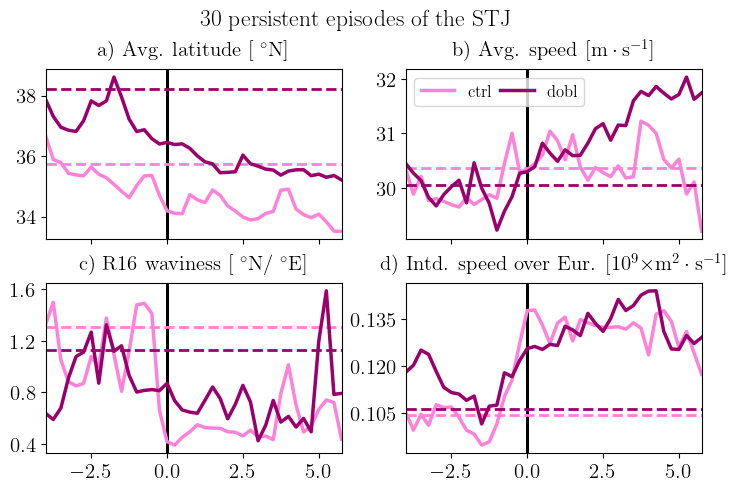

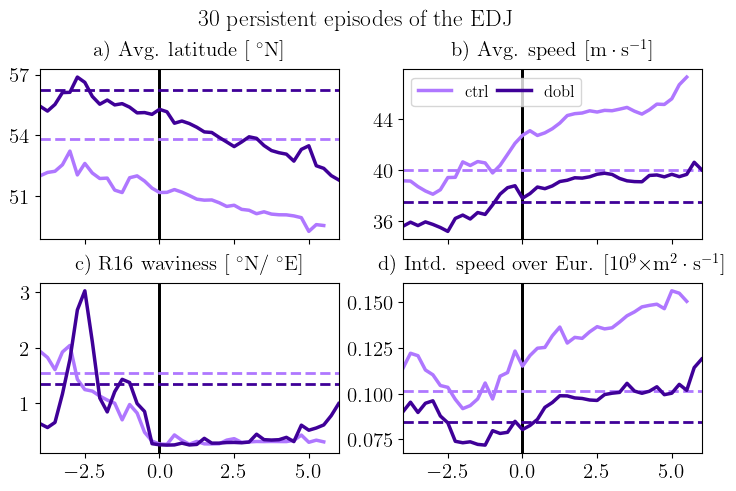

In [87]:
from jetutils.plots import COLORS_EXT
from string import ascii_lowercase

from scipy.stats import chi2, norm, t

data_vars = [
    # "mean_lon",
    "mean_lat",
    # "mean_theta",
    "mean_s",
    # "width",
    # "tilt",
    # "waviness1",
    # "waviness2",
    # "wavinessDC16",
    # "wavinessFV15",
    "wavinessR16",
    # "mean_lat_var",
    # "mean_s_var",
    # "is_polar",
    # "int",
    "int_over_europe",
    # "pers",
]

nrows: int = 2
ncols: int = 2

def func(col):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).var()
    return pl.col(col).mean()

colors = {
    "ctrl_STJ": COLORS_EXT[6],
    "ctrl_EDJ": COLORS_EXT[3],
    "dobl_STJ": COLORS_EXT[8],
    "dobl_EDJ": COLORS_EXT[5],
}

linestyles = {
    "ctrl_STJ": "solid",
    "ctrl_EDJ": "solid",
    "dobl_STJ": "solid",
    "dobl_EDJ": "solid",
}

for spell_of in ["STJ", "EDJ"]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.4), tight_layout=False, sharex="all")
    axes = axes.ravel()
    for exp_ in ["ctrl", "dobl"]:
        spells_from_jet = all_spells[f"{exp_}_{spell_of}"].drop("pers")
        n_spells = spells_from_jet["spell"].n_unique()
        props = props_ctrl if exp_ == "ctrl" else props_dobl
        props_masked = mask_from_spells_pl(
            spells_from_jet, props, time_before=datetime.timedelta(days=4)
        )
        props_masked = props_masked.filter(
            pl.col("spell").n_unique().over("relative_index") > 14
        )
        aggs = {col: func(col) for col in data_vars}
        aggs = aggs | {"alive": pl.col("time").len()}
        mean_ps = props_masked.group_by(
            ["relative_index", "jet"], maintain_order=True
        ).agg(**aggs)
        props_summer = props_ctrl_summer if exp_ == "ctrl" else props_dobl_summer
        means = props_summer.group_by("jet", maintain_order=True).agg(**aggs)
        alive_spells = (
            props_masked.group_by("relative_index")
            .agg(pl.col("spell").n_unique())
            .sort("relative_index")["spell"]
            .to_numpy()
        )
        j = int(spell_of=="EDJ")
        jet = spell_of
        # for j, jet in enumerate(["STJ", "EDJ"]):
        color = colors[f"{exp_}_{jet}"]
        linestyle = linestyles[f"{exp_}_{jet}"]
        to_plot = mean_ps.filter(pl.col("jet") == jet)
        x = to_plot["relative_index"].unique().to_numpy() / 4
        for ax, data_var, letter in zip(axes, data_vars, ascii_lowercase):
            factor = 1e9 if data_var in ["int_over_europe", "int"] else 1
            factor = 1e5 if data_var == "width" else factor
            ax.plot(x, to_plot[data_var] / factor, color=color, lw=2.5, linestyle=linestyle, label=f"{exp_}")
            mean = means.filter(pl.col("jet") == jet)[data_var].item() / factor
            ax.axhline(mean, color=color, ls="dashed", lw=2)
            factor_str = (
                "" if factor == 1 else rf"$10^{int(np.log10(factor))} \times $"
            )
            ax.set_title(
                rf"{letter}) {PRETTIER_VARNAME.get(data_var, data_var)} [{factor_str}{UNITS.get(data_var, '~')}]"
            )
            ax.yaxis.set_major_locator(MaxNLocator(4, integer=True))
        for i, ax in enumerate(axes):
            ax.axvline(0, zorder=1, color="black", lw=2)
            if i > 11:
                ax.set_xlabel("Relative time around onset [days]", color="black")
            ax.set_xlim(x[0], x[-1])
        axes[1].legend(ncol=2, columnspacing=0.5, fontsize=12, loc="upper left")
        fig.set_constrained_layout(True)
        fig.suptitle(f"{n_spells} persistent episodes of the {spell_of}")
        fig.savefig(f"{FIGURES}/Diabatic/oneper_{spell_of}_props.pdf")


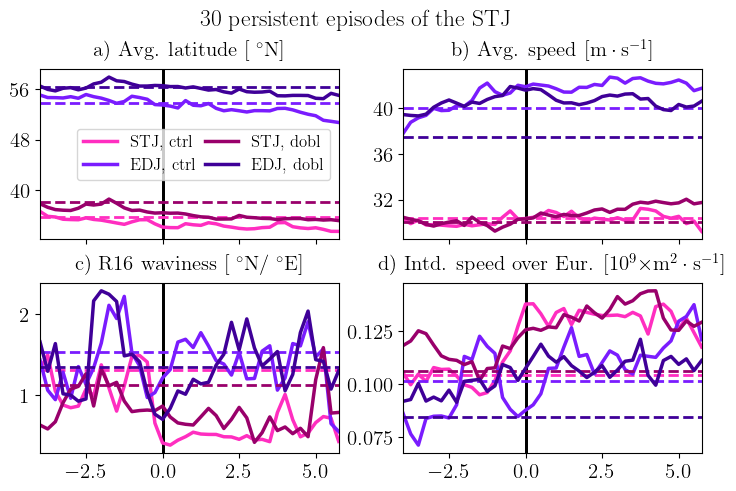

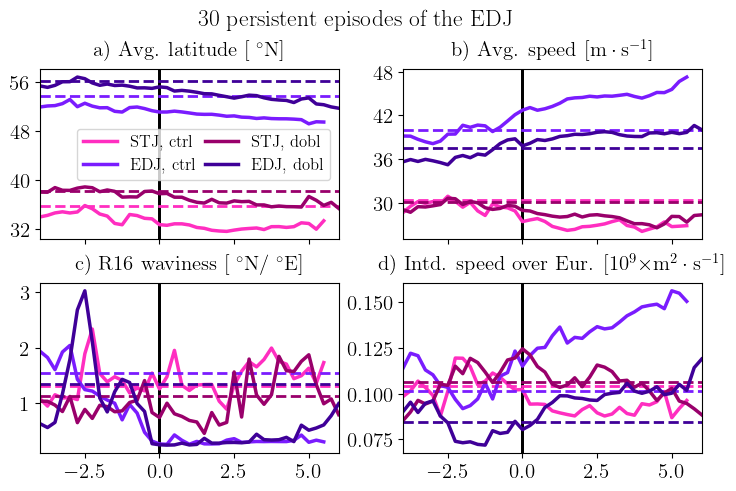

In [88]:
from jetutils.plots import COLORS_EXT
from string import ascii_lowercase

from scipy.stats import chi2, norm, t

data_vars = [
    # "mean_lon",
    "mean_lat",
    # "mean_theta",
    "mean_s",
    # "width",
    # "tilt",
    # "waviness1",
    # "waviness2",
    # "wavinessDC16",
    # "wavinessFV15",
    "wavinessR16",
    # "mean_lat_var",
    # "mean_s_var",
    # "is_polar",
    # "int",
    "int_over_europe",
    # "pers",
]

nrows: int = 2
ncols: int = 2

def func(col):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).var()
    return pl.col(col).mean()

colors = {
    "ctrl_STJ": COLORS[2],
    "ctrl_EDJ": COLORS[1],
    "dobl_STJ": COLORS_EXT[8],
    "dobl_EDJ": COLORS_EXT[5],
}

linestyles = {
    "ctrl_STJ": "solid",
    "ctrl_EDJ": "solid",
    "dobl_STJ": "solid",
    "dobl_EDJ": "solid",
}

for spell_of in ["STJ", "EDJ"]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.4), tight_layout=False, sharex="all")
    axes = axes.ravel()
    for exp_ in ["ctrl", "dobl"]:
        spells_from_jet = all_spells[f"{exp_}_{spell_of}"].drop("pers")
        n_spells = spells_from_jet["spell"].n_unique()
        props = props_ctrl if exp_ == "ctrl" else props_dobl
        props_masked = mask_from_spells_pl(
            spells_from_jet, props, time_before=datetime.timedelta(days=4)
        )
        props_masked = props_masked.filter(
            pl.col("spell").n_unique().over("relative_index") > 14
        )
        aggs = {col: func(col) for col in data_vars}
        aggs = aggs | {"alive": pl.col("time").len()}
        mean_ps = props_masked.group_by(
            ["relative_index", "jet"], maintain_order=True
        ).agg(**aggs)
        props_summer = props_ctrl_summer if exp_ == "ctrl" else props_dobl_summer
        means = props_summer.group_by("jet", maintain_order=True).agg(**aggs)
        alive_spells = (
            props_masked.group_by("relative_index")
            .agg(pl.col("spell").n_unique())
            .sort("relative_index")["spell"]
            .to_numpy()
        )
        for j, jet in enumerate(["STJ", "EDJ"]):
            color = colors[f"{exp_}_{jet}"]
            linestyle = linestyles[f"{exp_}_{jet}"]
            to_plot = mean_ps.filter(pl.col("jet") == jet)
            x = to_plot["relative_index"].unique().to_numpy() / 4
            for ax, data_var, letter in zip(axes, data_vars, ascii_lowercase):
                factor = 1e9 if data_var in ["int_over_europe", "int"] else 1
                factor = 1e5 if data_var == "width" else factor
                ax.plot(x, to_plot[data_var] / factor, color=color, lw=2.5, linestyle=linestyle, label=f"{jet}, {exp_}")
                mean = means.filter(pl.col("jet") == jet)[data_var].item() / factor
                ax.axhline(mean, color=color, ls="dashed", lw=2)
                if j == 0:
                    factor_str = (
                        "" if factor == 1 else rf"$10^{int(np.log10(factor))} \times $"
                    )
                    ax.set_title(
                        rf"{letter}) {PRETTIER_VARNAME.get(data_var, data_var)} [{factor_str}{UNITS.get(data_var, '~')}]"
                    )
                ax.yaxis.set_major_locator(MaxNLocator(4, integer=True))
        for i, ax in enumerate(axes):
            ax.axvline(0, zorder=1, color="black", lw=2)
            if i > 11:
                ax.set_xlabel("Relative time around onset [days]", color="black")
            ax.set_xlim(x[0], x[-1])
        axes[0].legend(ncol=2, columnspacing=0.5, fontsize=12)
        fig.set_constrained_layout(True)
        fig.suptitle(f"{n_spells} persistent episodes of the {spell_of}")
        fig.savefig(f"{FIGURES}/Diabatic/both_{spell_of}_props.pdf")


# RWB stats

In [89]:
df = {"ctrl": [], "dobl": []}
for exp_ in ["ctrl", "dobl"]:
    for year in range(1969, 2021):
        f = f"{DATADIR}/Henrik_data/rwb_{exp_}/overturnings_{year}.parquet"
        df[exp_].append(pl.read_parquet(f))
    df[exp_] = pl.concat(df[exp_]).sort("time", "level", "index")
    unique_levs = df[exp_]["level"].unique()
    if len(unique_levs) > 1:
        df[exp_] = df[exp_].filter(pl.col("level") == unique_levs[2])
    df[exp_] = df[exp_].with_columns(pl.col("area") / 1e13)
    df[exp_] = df[exp_].with_columns(
        sum_areas=pl.col("area").sum().over("time", "level"),
        sum_mflux=pl.col("mflux").sum().over("time", "level"),
    )

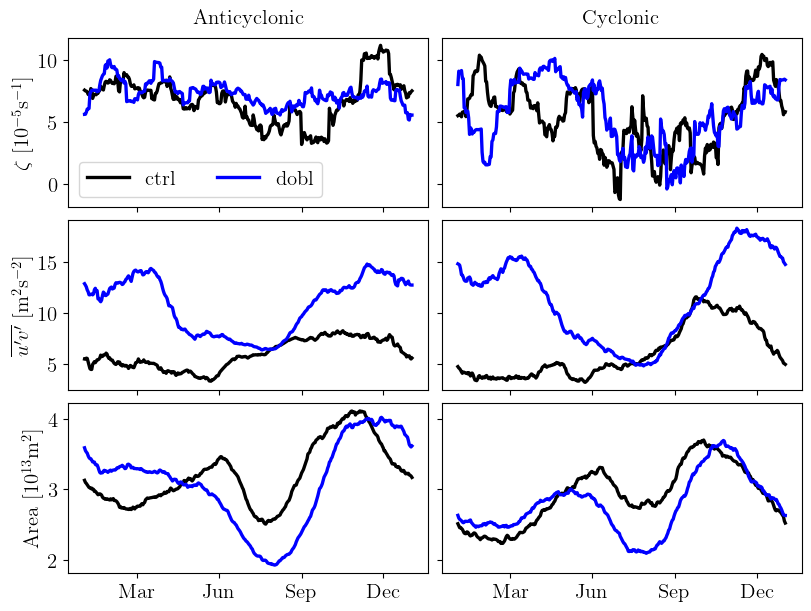

In [90]:
fig, axes = plt.subplots(3, 2, figsize=(8, 6), sharex="all", sharey="row", constrained_layout=True)
axes = axes.T
colors = {"ctrl": "black", "dobl": "blue", "ctrl_p4": "red"}
prettier_varname = {
    "zeta": r"$\zeta$ [$10^{-5}\mathrm{s^{-1}}$]",
    "mflux": r"$\overline{u'v'}$ [$\mathrm{m^2s^{-2}}$]",
    "sum_mflux": r"$\sum \overline{u'v'}$ [$\mathrm{m^2s^{-2}}$]",
    "area": r"Area [$10^{13}\mathrm{m^{2}}$]",
    "sum_areas": r"Area sum [$10^{13}\mathrm{m^{2}}$]",
}
prettier_orientation = {
    "anticyclonic": "Anticyclonic",
    "cyclonic": "Cyclonic",
}
for orientation, axs in zip(["anticyclonic", "cyclonic"], axes):
    axs[0].set_title(prettier_orientation[orientation])
    for var, ax in zip(["zeta", "mflux", "area"], axs):
        if orientation == "anticyclonic":
            ax.set_ylabel(prettier_varname[var])
        for key, df_ in df.items():
            if key == "ctrl_p4":
                continue
            df_ = df_.drop("points", "side", "geometry").filter(pl.col("orientation") == orientation)
            gb = df_.group_by(pl.col("time").dt.ordinal_day().alias("dayofyear"), "level")
            mean = gb.agg(pl.col(var).mean()).sort("dayofyear", "level")
            mean = periodic_rolling_pl(mean, 31, [var], other_columns=["level"])
            std = gb.agg(pl.col(var).std()).sort("dayofyear", "level")
            std = periodic_rolling_pl(std, 31, [var], other_columns=["level"])
            q25 = gb.agg(pl.col(var).quantile(0.4)).sort("dayofyear", "level")
            q25 = periodic_rolling_pl(q25, 31, [var], other_columns=["level"])
            q75 = gb.agg(pl.col(var).quantile(0.6)).sort("dayofyear", "level")
            q75 = periodic_rolling_pl(q75, 31, [var], other_columns=["level"])
            median = gb.agg(pl.col(var).median()).sort("dayofyear", "level")
            median = periodic_rolling_pl(median, 31, [var], other_columns=["level"])
            # if var != "zeta":
            #     ax.fill_between(mean["dayofyear"], mean[var] - std[var] / 10, mean[var] + std[var] / 10, alpha=0.4, color=colors[key])
                # ax.fill_between(mean["dayofyear"], q25[var], q75[var], alpha=0.4, color=colors[key])
            ax.plot(mean["dayofyear"], mean[var], lw=2.4, color=colors[key], label=key)
            # ax.plot(mean["dayofyear"], median[var], lw=1.4, ls="dashed", color=colors[key])
        ax.xaxis.set_major_locator(MonthLocator(range(0, 13, 3)))
        ax.xaxis.set_major_formatter(DateFormatter("%b"))
axes[0, 0].legend(ncol=2)
fig.savefig(f"{FIGURES}/Diabatic/rwb_props.pdf")